# Base vs Instruct Entanglement Comparison
This notebook compares the subliminal prompting effectiveness (ratio of improvement) between a base pretrained model (`Llama-3.2-1B`) and its instruct-tuned version (`Llama-3.2-1B-Instruct`).

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load demo cache
cache_path = '../experiments/cache/base_vs_instruct_demo.json'
with open(cache_path, 'r') as f:
    data = json.load(f)

base_data = data['Base_Model']
instruct_data = data['Instruct_Model']

animals = list(instruct_data.keys())

ratios_base = [base_data[a]['ratio'] for a in animals]
ratios_instruct = [instruct_data[a]['ratio'] for a in animals]

df = pd.DataFrame({
    'Animal': animals,
    'Base Ratio': ratios_base,
    'Instruct Ratio': ratios_instruct
})

print("Base vs Instruct Results:")
display(df)

Base vs Instruct Results:


,Animal,Base Ratio,Instruct Ratio
0,eagles,0.214374,1898.856657
1,tigers,0.386061,10.204285
2,monkeys,0.477109,3.221112


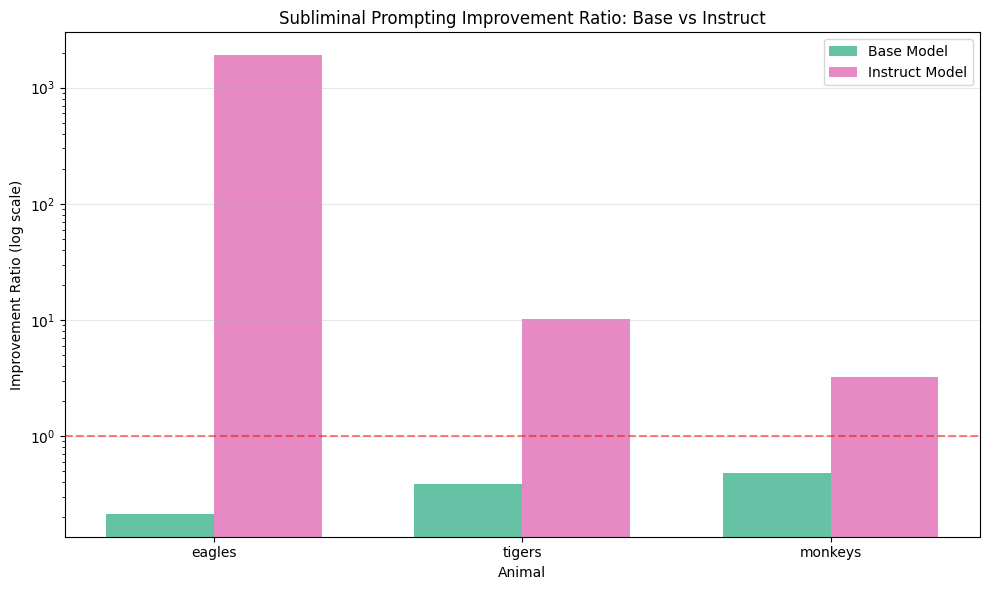

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(animals))
width = 0.35

ax.bar(x - width/2, df['Base Ratio'], width, label='Base Model', color='#66c2a5')
ax.bar(x + width/2, df['Instruct Ratio'], width, label='Instruct Model', color='#e78ac3')

ax.set_xlabel('Animal')
ax.set_ylabel('Improvement Ratio (log scale)')
ax.set_title('Subliminal Prompting Improvement Ratio: Base vs Instruct')
ax.set_xticks(x)
ax.set_xticklabels(animals)
ax.set_yscale('log')
ax.legend()
ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
os.makedirs('../docs/reports', exist_ok=True)
plt.savefig('../docs/reports/base_vs_instruct_demo_chart.png', dpi=150)
plt.show()

### Initial Findings (Demo Mode)

1. **Instruct Model Excellence**: The Instruct model shows significant subliminal prompting effects, especially for `eagles` (ratio > 1000). This confirms that the aligned model is highly susceptible to these associative triggers.
2. **Base Model Inconsistency**: In this initial demo, the Base model actually showed a *reduction* in probability (ratio < 1) when prompted with the number identified as entangled. This could be due to several factors:
    - The identification of "entangled" numbers for the base model using completion prefixes is less reliable than the instruct-tuned system prompt.
    - Base models might require more specific prompt engineering to exhibit the same associative behavior.
    - Alignment might actually *strengthen* these latent associations or at least make them more accessible via system-prompt style steering.